<a href="https://colab.research.google.com/github/mipaillafil/telco-ml-e1/blob/main/machine_telco_limpio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Telco Customer Churn — Exploración y limpieza**

**Objetivo:** comprender el dataset, revisar su calidad, identificar patrones de abandono y realizar la limpieza inicial.

Esta etapa corresponde principalmente a las fases de Comprensión del negocio, Comprensión de los datos y Preparación de los datos de CRISP-DM.

##**Importación de Librerias**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##**Cargar Dataset**

In [66]:
sns.set_theme(style="whitegrid")

df= pd.read_csv('https://raw.githubusercontent.com/mipaillafil/telco-ml-e1/main/data/raw/Telco_Customer_Churn_Dataset.csv')

print("Dataset cargado correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Dataset cargado correctamente
Filas: 7043
Columnas: 21


##**Revision Inicial de los Datos**

In [36]:
display(df.head())
print("\nInformación del dataset:")
df.info()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [37]:
print("Dimensiones:", df.shape)

print("\nEstadísticas descriptivas:")
display(df.describe())


Dimensiones: (7043, 21)

Estadísticas descriptivas:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


##**Calidad de los Datos**

In [38]:
print("Valores nulos:")
print(df.isnull().sum().sort_values(ascending=False))


Valores nulos:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [39]:
print("\nRegistros duplicados:", df.duplicated().sum())


Registros duplicados: 0


In [40]:
print("\nValores vacíos por columna:")
print((df.astype(str).apply(lambda col: col.str.strip().eq("").sum())))


Valores vacíos por columna:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


##**Revision TotalCharges**

In [41]:
vacios_total = df["TotalCharges"].astype(str).str.strip().eq("")

print("Cantidad de TotalCharges vacíos:", vacios_total.sum())

display(
    df.loc[vacios_total, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
)


Cantidad de TotalCharges vacíos: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [49]:
# Convertimos los espacios vacíos en valores faltantes
df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True)

# Convertimos TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Valores faltantes en TotalCharges después de la conversión:",
      df["TotalCharges"].isnull().sum())


Valores faltantes en TotalCharges después de la conversión: 11


In [50]:
# Los registros con TotalCharges faltante corresponden a clientes con tenure = 0.
# Por eso se imputan con 0.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Valores faltantes después del tratamiento:")
display(df.isnull().sum().sort_values(ascending=False))


Valores faltantes después del tratamiento:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##**Distribución de la Variable Objetivo**

In [52]:
print(df["Churn"].value_counts())

print("\nPorcentaje:")
display(df["Churn"].value_counts(normalize=True).mul(100).round(2))


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje:


,proportion
Churn,
No,73.46
Yes,26.54


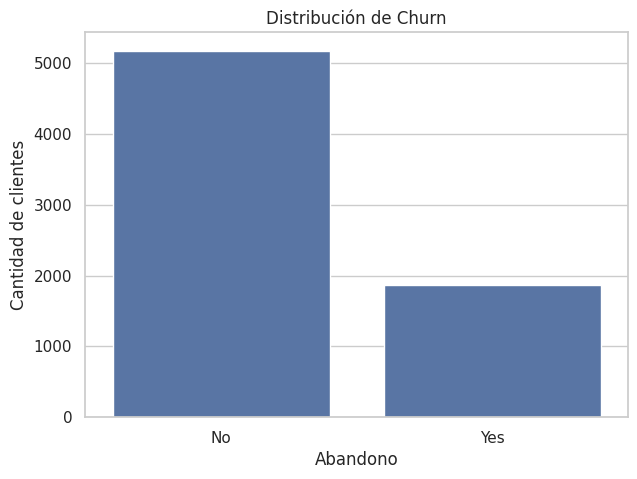

In [53]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Churn")
plt.title("Distribución de Churn")
plt.xlabel("Abandono")
plt.ylabel("Cantidad de clientes")
plt.show()


##**Análisis Exploratorio de Variables Relevantes**

###**Churn según tipo de contrato**

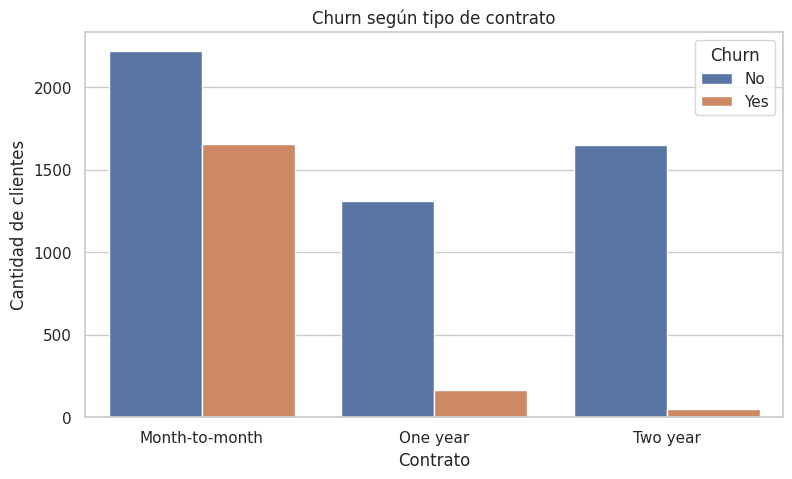

In [54]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn según tipo de contrato")
plt.xlabel("Contrato")
plt.ylabel("Cantidad de clientes")
plt.show()


###**Churn según servicio de Internet**

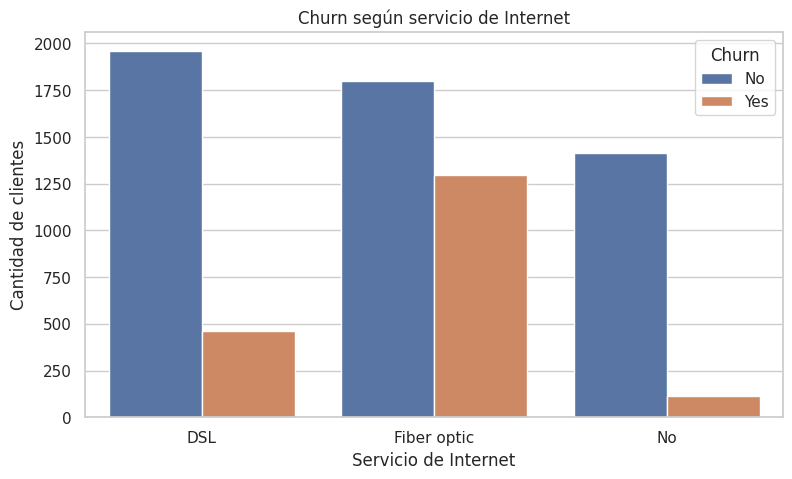

In [56]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn según servicio de Internet")
plt.xlabel("Servicio de Internet")
plt.ylabel("Cantidad de clientes")
plt.show()

###**Churn según método de pago**

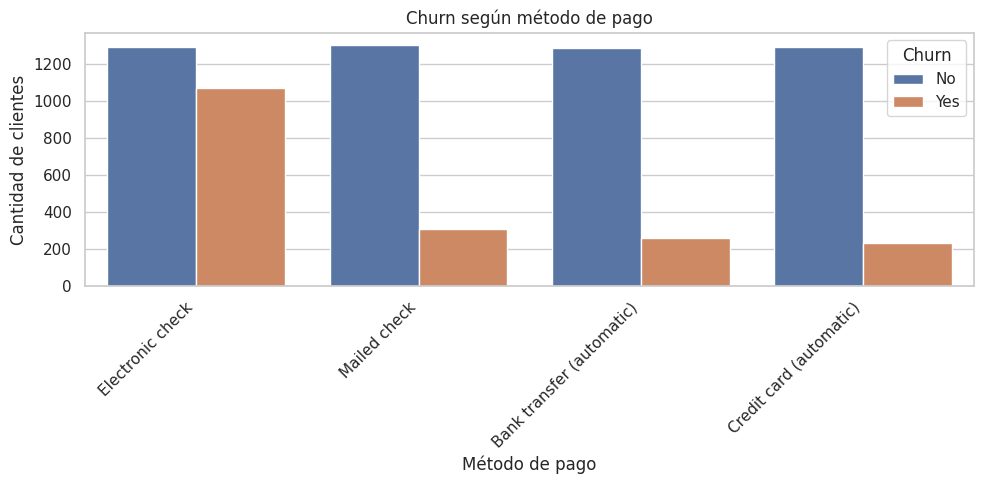

In [57]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

###**Antigüedad según Churn**

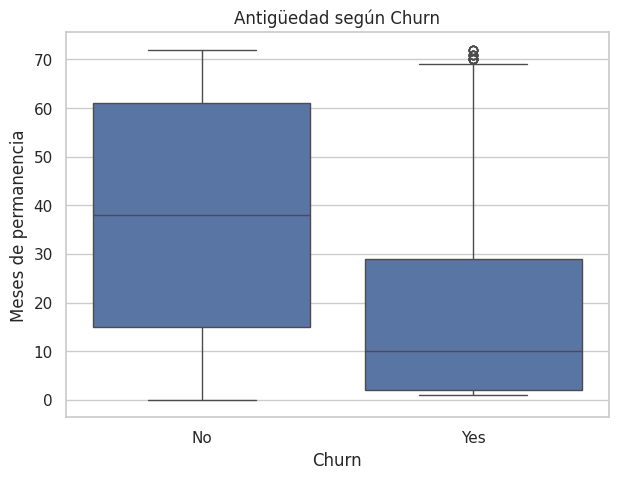

In [59]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Antigüedad según Churn")
plt.xlabel("Churn")
plt.ylabel("Meses de permanencia")
plt.show()

###**Cargo mensual según Churn**

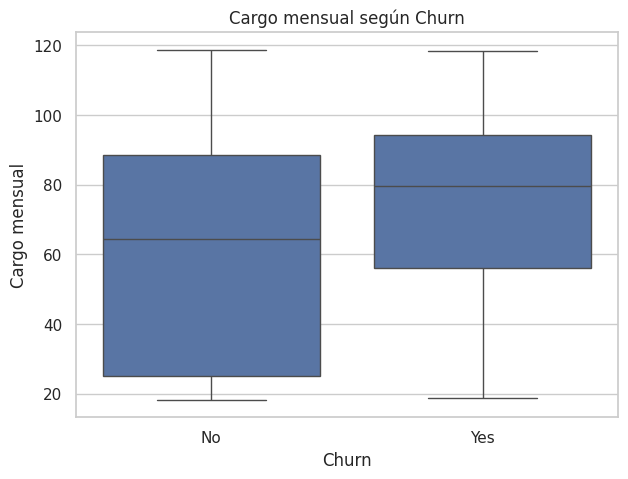

In [61]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Cargo mensual según Churn")
plt.xlabel("Churn")
plt.ylabel("Cargo mensual")
plt.show()

###**Churn según soporte técnico**

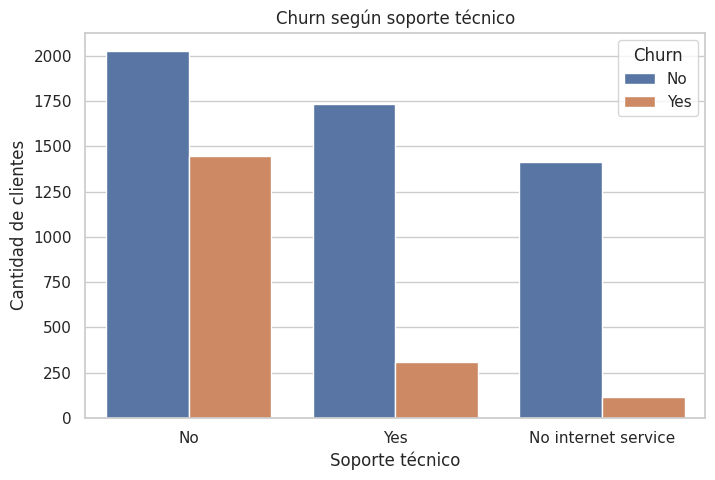

In [62]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="TechSupport", hue="Churn")
plt.title("Churn según soporte técnico")
plt.xlabel("Soporte técnico")
plt.ylabel("Cantidad de clientes")
plt.show()

##**Posibles Patrones Observados**

Basándonos en el análisis exploratorio realizado, se pueden observar los siguientes patrones con respecto al abandono de clientes (Churn):

*   **Tipo de Contrato:** Los clientes con contratos mensuales tienen una tasa de abandono significativamente mayor en comparación con aquellos con contratos de uno o dos años. Esto sugiere que los contratos a largo plazo fomentan la lealtad.
*   **Servicio de Internet:** Los clientes con servicio de internet de fibra óptica parecen tener una mayor tasa de churn que aquellos con DSL. Esto podría indicar problemas con la calidad del servicio de fibra óptica o una mayor competencia en ese segmento.
*   **Método de Pago:** Los clientes que utilizan métodos de pago electrónicos (Cheque electrónico) muestran una tasa de abandono más alta. Esto podría estar relacionado con la facilidad de cambiar de proveedor.
*   **Antigüedad (Tenure):** Existe una clara relación inversa entre la antigüedad del cliente y el Churn; los clientes con menos meses de permanencia son más propensos a abandonar la empresa. Esto se observa en los boxplots, donde los clientes que abandonan tienen una antigüedad media mucho menor.
*   **Cargos Mensuales:** Los clientes con cargos mensuales más altos tienden a tener una mayor tasa de Churn. Esto sugiere que el precio es un factor importante en la decisión de los clientes de quedarse o irse.
*   **Soporte Técnico:** Los clientes que no tienen soporte técnico son más propensos a abandonar. Esto subraya la importancia de un buen servicio de atención al cliente para la retención.

##**Limpieza Final**
CustomerID es un identificador único. Se elimina antes del modelamiento porque no representa una caracteristica útil del comportamiento del cliente.

In [63]:
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

assert df.isnull().sum().sum() == 0

print("Valores nulos restantes:", df.isnull().sum().sum())
print("Dimensiones finales:", df.shape)

Valores nulos restantes: 0
Dimensiones finales: (7043, 20)


In [65]:
df.to_csv("Telco_Customer_Churn_Clean.csv",index=False)
print("Dataset limpio guardado correctamente.")

Dataset limpio guardado correctamente.


##**Conclusión del Análisis Exploratorio y Limpieza**

Este análisis exploratorio inicial ha revelado patrones clave que influyen en el `Churn` de clientes en Telco. Se observó que el tipo de contrato (mensual), el servicio de internet (fibra óptica), el método de pago (cheque electrónico), la baja antigüedad (`tenure`), y los altos cargos mensuales son factores que contribuyen significativamente al abandono. La limpieza de datos, incluyendo la gestión de valores nulos en `TotalCharges` y la eliminación de `customerID`, ha preparado el dataset para futuras etapas de modelado predictivo. Estos hallazgos son cruciales para desarrollar estrategias de retención de clientes más efectivas.